In [1]:
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import plotly.graph_objects as go

from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold

from gtda.pipeline import Pipeline
from gtda.homology import VietorisRipsPersistence
from gtda.time_series import TakensEmbedding
from gtda.diagrams import PersistenceEntropy, BettiCurve, PersistenceImage
from gtda.metaestimators import CollectionTransformer

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))

from tda_slugging.utils import read_files, find_shortest_file, batch_analyzer, mutual_information

DATA_3W_ALL      = str(REPO_ROOT / 'data' / '3W' / 'ALL')
DATA_3W_REAL     = str(REPO_ROOT / 'data' / '3W' / 'REAL')
DATA_3W_SIM      = str(REPO_ROOT / 'data' / '3W' / 'SIMULATED')
DATA_WELL        = str(REPO_ROOT / 'data' / 'well')
OUTPUTS_DIR      = str(REPO_ROOT / 'outputs')
IMAGES_DIR       = str(REPO_ROOT / 'images')
DATA_3W_NORMAL   = '/Users/simo/Repos/TDA/Slugging/Data/3W_data/0'
DATA_3W_UNSTABLE = '/Users/simo/Repos/TDA/Slugging/Data/3W_data/4'

## 2. Load data

Load wellhead pressure (P-TPT) for all three flow regimes, resample to 3 000 points, convert Pa → Bar.

In [3]:
PA_TO_BAR = 1e-5

slugging_signals, slugging_df   = read_files(DATA_3W_ALL,      "P-TPT", 3000)
normal_signals,   normal_df     = read_files(DATA_3W_NORMAL,   "P-TPT", 3000)
unstable_signals, unstable_df   = read_files(DATA_3W_UNSTABLE, "P-TPT", 3000)

slugging_signals  *= PA_TO_BAR;  slugging_df  = slugging_df.apply(lambda x: x * PA_TO_BAR)
normal_signals    *= PA_TO_BAR;  normal_df    = normal_df.apply(lambda x: x * PA_TO_BAR)
unstable_signals  *= PA_TO_BAR;  unstable_df  = unstable_df.apply(lambda x: x * PA_TO_BAR)

print(f"Slugging : {slugging_signals.shape[0]:4d} time series")
print(f"Normal   : {normal_signals.shape[0]:4d} time series")
print(f"Unstable : {unstable_signals.shape[0]:4d} time series")

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

...

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data_df = pd.read_csv(os.path.join(path, file)).interpolate()
/Users/simo/Repos/TDA/Slugging/repo/src/tda_slugging/utils.py:33: FutureWarning: DataFrame.interpola

Slugging :  106 time series
Normal   :  597 time series
Unstable :  344 time series


## 3. Persistence-image pipeline

Build a giotto-tda pipeline: Takens embedding → Vietoris–Rips persistence → Persistence image (100×100, σ=1.0).

In [4]:
def make_pi_pipeline(time_delay, dimension, stride=3):
    return Pipeline([
        ("embedder",    TakensEmbedding(time_delay=time_delay, dimension=dimension, stride=stride)),
        ("persistence", VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
        ("image",       PersistenceImage(n_bins=100, sigma=1.0)),
    ])

# Normal and slugging share the same optimal embedding parameters
pipeline_ns = make_pi_pipeline(time_delay=85,  dimension=9)
# Unstable flow uses a longer embedding window
pipeline_u  = make_pi_pipeline(time_delay=125, dimension=9)

In [5]:
print("Computing persistence images for slugging data ...")
Per_images_slugging = pipeline_ns.fit_transform(slugging_signals)

print("Computing persistence images for normal data ...")
Per_images_normal   = pipeline_ns.fit_transform(normal_signals)

print("Computing persistence images for unstable data ...")
Per_images_unstable = pipeline_u.fit_transform(unstable_signals)

print(f"\nShapes — slugging: {Per_images_slugging.shape},  "
      f"normal: {Per_images_normal.shape},  "
      f"unstable: {Per_images_unstable.shape}")

Computing persistence images for slugging data ...


/Users/simo/Library/Caches/pypoetry/virtualenvs/tda-TgTABIFl-py3.9/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Computing persistence images for normal data ...


/Users/simo/Library/Caches/pypoetry/virtualenvs/tda-TgTABIFl-py3.9/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Computing persistence images for unstable data ...


/Users/simo/Library/Caches/pypoetry/virtualenvs/tda-TgTABIFl-py3.9/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Shapes — slugging: (106, 2, 100, 100),  normal: (597, 2, 100, 100),  unstable: (344, 2, 100, 100)


## 4. Binary classification: Normal vs. Slugging

Labels: 0 = Normal, 1 = Slugging.

In [6]:
def flatten_dim(per_images, dim):
    """Extract homology dimension *dim* and flatten each 100x100 image to 10 000 features."""
    return np.array([img.flatten() for img in per_images[:, dim, :, :]])

# Flatten
ns_H0 = np.vstack([flatten_dim(Per_images_normal,   0), flatten_dim(Per_images_slugging, 0)])
ns_H1 = np.vstack([flatten_dim(Per_images_normal,   1), flatten_dim(Per_images_slugging, 1)])

labels_binary = np.append(np.zeros(len(Per_images_normal)), np.ones(len(Per_images_slugging)))
ft_binary = ['Normal', 'Slugging']

X_tr_H0, X_te_H0, y_tr_H0, y_te_H0 = train_test_split(ns_H0, labels_binary, test_size=0.35, random_state=242)
X_tr_H1, X_te_H1, y_tr_H1, y_te_H1 = train_test_split(ns_H1, labels_binary, test_size=0.35, random_state=153)

In [7]:
def show_cm(y_true, y_pred, labels, title=""):
    cm   = metrics.confusion_matrix(y_true, y_pred)
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

def show_metrics(y_true, y_pred):
    r = metrics.recall_score(y_true, y_pred, average='macro')
    p = metrics.precision_score(y_true, y_pred, average='macro')
    f = metrics.f1_score(y_true, y_pred, average='macro')
    print(f"Recall: {r:.4f}  Precision: {p:.4f}  F1: {f:.4f}")

LR on H0 accuracy: 1.0000


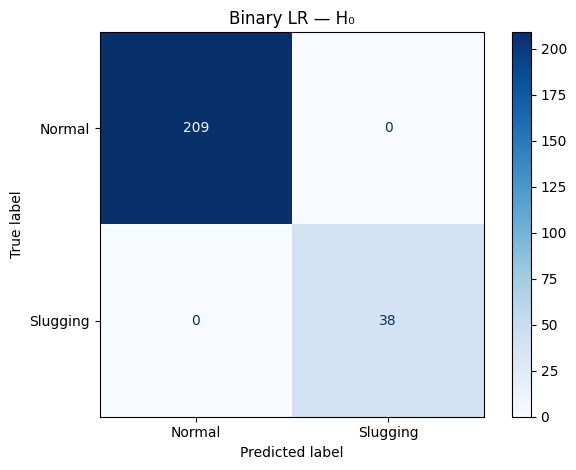

Recall: 1.0000  Precision: 1.0000  F1: 1.0000



LR on H1 accuracy: 0.9879


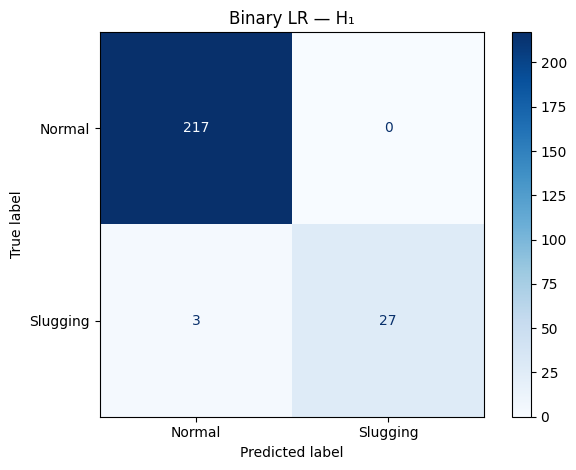

Recall: 0.9500  Precision: 0.9932  F1: 0.9703


In [8]:
lr_bin = LogisticRegression(max_iter=1000)

lr_bin.fit(X_tr_H0, y_tr_H0)
y_pred_H0 = lr_bin.predict(X_te_H0)
print(f"LR on H0 accuracy: {lr_bin.score(X_te_H0, y_te_H0):.4f}")
show_cm(y_te_H0, y_pred_H0, ft_binary, "Binary LR — H₀")
show_metrics(y_te_H0, y_pred_H0)

lr_bin.fit(X_tr_H1, y_tr_H1)
y_pred_H1 = lr_bin.predict(X_te_H1)
print(f"\nLR on H1 accuracy: {lr_bin.score(X_te_H1, y_te_H1):.4f}")
show_cm(y_te_H1, y_pred_H1, ft_binary, "Binary LR — H₁")
show_metrics(y_te_H1, y_pred_H1)

## 5. Ternary classification: persistence images

Add *Unstable* (label = 2) and repeat classification.

In [9]:
# Build ternary feature matrices and label array
labels_unstable = np.full(len(Per_images_unstable), 2)
labels_total = np.concatenate([labels_binary, labels_unstable])

imgs_H0 = np.vstack([ns_H0, flatten_dim(Per_images_unstable, 0)])
imgs_H1 = np.vstack([ns_H1, flatten_dim(Per_images_unstable, 1)])

ft_ternary = ['Normal', 'Slugging', 'Unstable']

X_trH0, X_teH0, y_trH0, y_teH0 = train_test_split(imgs_H0, labels_total, test_size=0.35, random_state=242)
X_trH1, X_teH1, y_trH1, y_teH1 = train_test_split(imgs_H1, labels_total, test_size=0.35, random_state=153)

# Class balance
for split_name, y_split in [("Train", y_trH0), ("Test", y_teH0)]:
    counts = {0: (y_split==0).sum(), 1: (y_split==1).sum(), 2: (y_split==2).sum()}
    print(f"{split_name}: Normal={counts[0]}  Slugging={counts[1]}  Unstable={counts[2]}  Total={len(y_split)}")

Train: Normal=399  Slugging=63  Unstable=218  Total=680
Test: Normal=198  Slugging=43  Unstable=126  Total=367


LR H0 accuracy: 0.9973


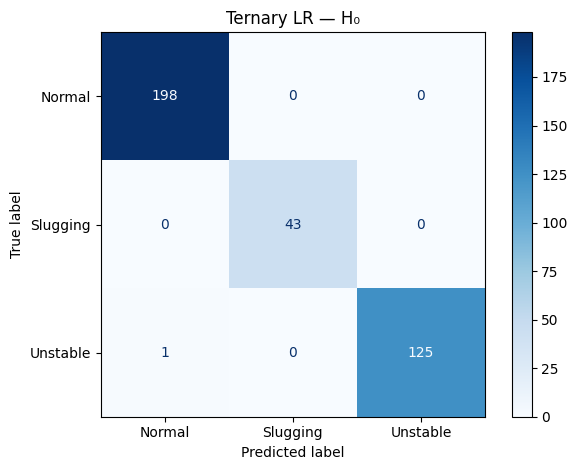

Recall: 0.9974  Precision: 0.9983  F1: 0.9978


In [10]:
# Logistic Regression on H0
lr = LogisticRegression(multi_class="multinomial", max_iter=1000)
lr.fit(X_trH0, y_trH0)
y_pred = lr.predict(X_teH0)
print(f"LR H0 accuracy: {lr.score(X_teH0, y_teH0):.4f}")
show_cm(y_teH0, y_pred, ft_ternary, "Ternary LR — H₀")
show_metrics(y_teH0, y_pred)

LR H1 accuracy: 0.9564


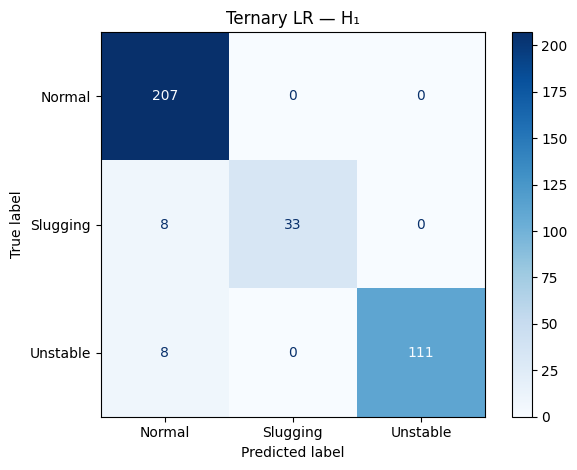

Recall: 0.9126  Precision: 0.9761  F1: 0.9400


In [11]:
# Logistic Regression on H1
lr.fit(X_trH1, y_trH1)
y_pred = lr.predict(X_teH1)
print(f"LR H1 accuracy: {lr.score(X_teH1, y_teH1):.4f}")
show_cm(y_teH1, y_pred, ft_ternary, "Ternary LR — H₁")
show_metrics(y_teH1, y_pred)

RF H0 accuracy: 0.9973


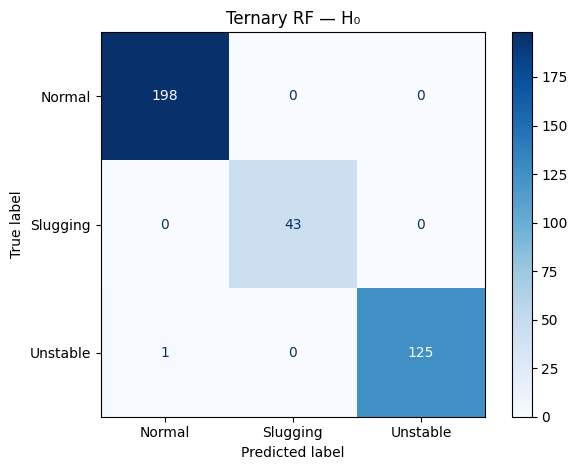

Recall: 0.9974  Precision: 0.9983  F1: 0.9978


In [12]:
# Random Forest on H0
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_trH0, y_trH0)
y_pred = clf.predict(X_teH0)
print(f"RF H0 accuracy: {clf.score(X_teH0, y_teH0):.4f}")
show_cm(y_teH0, y_pred, ft_ternary, "Ternary RF — H₀")
show_metrics(y_teH0, y_pred)

RF H1 accuracy: 0.9673


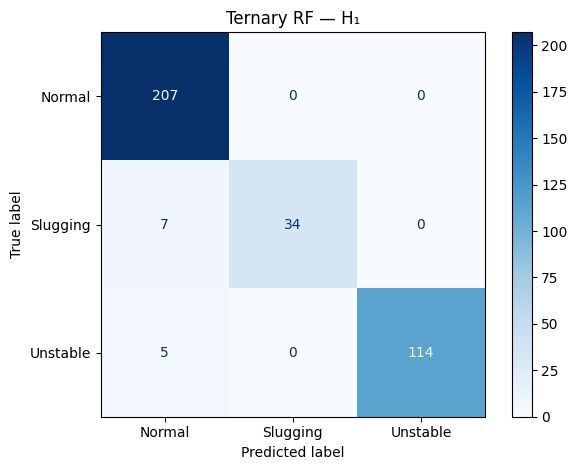

Recall: 0.9291  Precision: 0.9817  F1: 0.9523


In [13]:
# Random Forest on H1
clf.fit(X_trH1, y_trH1)
y_pred = clf.predict(X_teH1)
print(f"RF H1 accuracy: {clf.score(X_teH1, y_teH1):.4f}")
show_cm(y_teH1, y_pred, ft_ternary, "Ternary RF — H₁")
show_metrics(y_teH1, y_pred)

LR combined accuracy: 0.9973


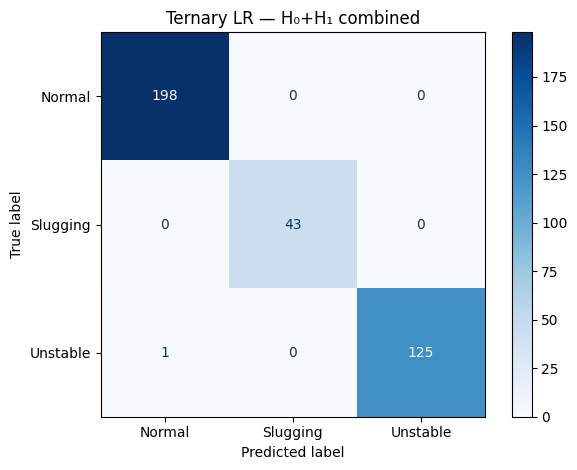

Recall: 0.9974  Precision: 0.9983  F1: 0.9978



RF combined accuracy: 0.9973


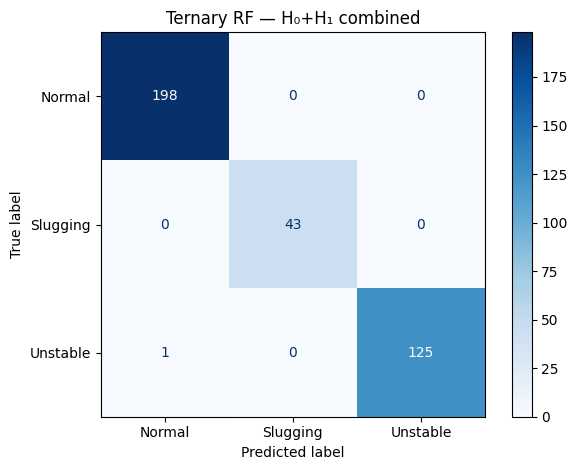

Recall: 0.9974  Precision: 0.9983  F1: 0.9978


In [14]:
# Combined H0 + H1 (element-wise sum, matching original analysis)
imgs_combined = imgs_H0 + imgs_H1
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(imgs_combined, labels_total, test_size=0.35, random_state=242)

lr_c = LogisticRegression(multi_class="multinomial", max_iter=5000, solver='saga')
lr_c.fit(X_tr_c, y_tr_c)
y_pred_c = lr_c.predict(X_te_c)
print(f"LR combined accuracy: {lr_c.score(X_te_c, y_te_c):.4f}")
show_cm(y_te_c, y_pred_c, ft_ternary, "Ternary LR — H₀+H₁ combined")
show_metrics(y_te_c, y_pred_c)

clf_c = RandomForestClassifier(n_estimators=100, random_state=42)
clf_c.fit(X_tr_c, y_tr_c)
y_pred_c_rf = clf_c.predict(X_te_c)
print(f"\nRF combined accuracy: {clf_c.score(X_te_c, y_te_c):.4f}")
show_cm(y_te_c, y_pred_c_rf, ft_ternary, "Ternary RF — H₀+H₁ combined")
show_metrics(y_te_c, y_pred_c_rf)

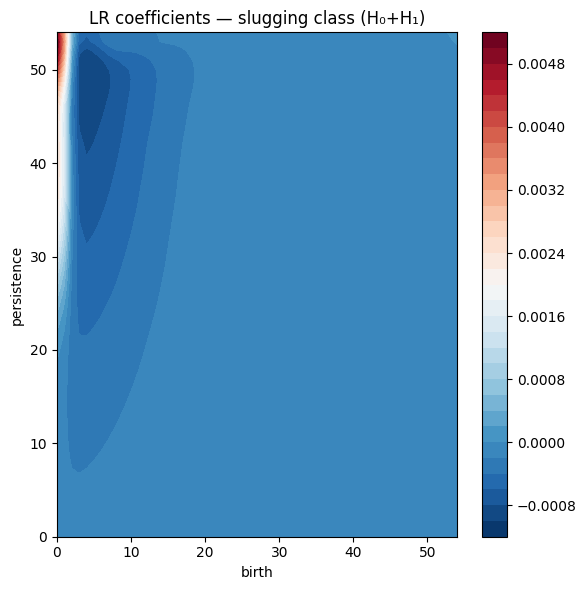

In [15]:
# Coefficient heatmap for slugging class (paper Fig. 11d)
coef_slug = lr_c.coef_[1].reshape(100, 100)
tmp = coef_slug[45:100, 0:55]

X = np.arange(0, 55)
Y = np.arange(0, 55)
XX, YY = np.meshgrid(X, Y)

fig, ax = plt.subplots(figsize=(6, 6))
cs = ax.contourf(XX, YY, tmp, levels=30, cmap='RdBu_r')
fig.colorbar(cs, ax=ax)
ax.set_title("LR coefficients — slugging class (H\u2080+H\u2081)")
ax.set_xlabel("birth"); ax.set_ylabel("persistence")
plt.tight_layout()
plt.savefig(IMAGES_DIR + "/LogReg_Coeff_Slug.png", dpi=150)
plt.show()

## 6. Topological-indicator features

Extract six scalar features per time series:
`[max_pers_H0, max_pers_H1, mean_betti_H0, mean_betti_H1, entropy_norm_H0, entropy_norm_H1]`

In [16]:
def extract_tda_features(signals, time_delay, dimension, stride=3):
    """Return array of shape (n_samples, 6) with TDA scalar features."""
    VRP    = VietorisRipsPersistence(homology_dimensions=(0, 1))
    PE_n   = PersistenceEntropy(normalize=True)
    Betti  = BettiCurve()

    embedder  = TakensEmbedding(time_delay=time_delay, dimension=dimension, stride=stride)
    clouds    = embedder.fit_transform(signals)
    diagrams  = VRP.fit_transform(clouds)
    ent_norm  = PE_n.fit_transform(diagrams)
    betti     = Betti.fit_transform(diagrams)

    mean_bH0 = [statistics.mean(betti[i, 0, :]) for i in range(len(betti))]
    mean_bH1 = [statistics.mean(betti[i, 1, :]) for i in range(len(betti))]

    max_pH0, max_pH1 = [], []
    for diag in diagrams:
        pH0 = [abs(p[1]-p[0]) for p in diag if p[2] == 0]
        pH1 = [abs(p[1]-p[0]) for p in diag if p[2] == 1]
        max_pH0.append(max(pH0) if pH0 else 0.0)
        max_pH1.append(max(pH1) if pH1 else 0.0)

    return np.stack([max_pH0, max_pH1, mean_bH0, mean_bH1,
                     ent_norm[:, 0], ent_norm[:, 1]], axis=-1)

In [17]:
print("Extracting features for normal flow   (delay=85,  dim=9) ...")
normal_features   = extract_tda_features(normal_signals,   time_delay=85,  dimension=9)

print("Extracting features for slugging flow  (delay=125, dim=7) ...")
slugging_features = extract_tda_features(slugging_signals,  time_delay=125, dimension=7)

print("Extracting features for unstable flow  (delay=125, dim=8) ...")
unstable_features = extract_tda_features(unstable_signals,  time_delay=125, dimension=8)

features_array = np.vstack([normal_features, slugging_features, unstable_features])
print(f"\nfeatures_array shape: {features_array.shape}  (expected 1047 × 6)")

Extracting features for normal flow   (delay=85,  dim=9) ...


Extracting features for slugging flow  (delay=125, dim=7) ...


Extracting features for unstable flow  (delay=125, dim=8) ...



features_array shape: (1047, 6)  (expected 1047 × 6)


In [18]:
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    features_array, labels_total, test_size=0.35, random_state=49)

for split_name, y_split in [("Train", y_tr_f), ("Test", y_te_f)]:
    counts = {0: (y_split==0).sum(), 1: (y_split==1).sum(), 2: (y_split==2).sum()}
    print(f"{split_name}: Normal={counts[0]}  Slugging={counts[1]}  Unstable={counts[2]}")

Train: Normal=397  Slugging=69  Unstable=214
Test: Normal=200  Slugging=37  Unstable=130


## 7. Ternary classification: topological indicators

LR accuracy: 0.9264


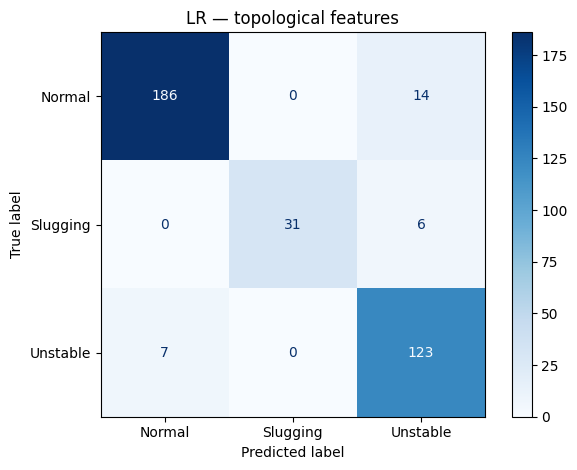

Recall: 0.9047  Precision: 0.9413  F1: 0.9198


In [19]:
# Logistic Regression (paper Fig. 10a)
lr_f = LogisticRegression(multi_class="multinomial", max_iter=5000, solver='saga')
lr_f.fit(X_tr_f, y_tr_f)
y_pred_f = lr_f.predict(X_te_f)
print(f"LR accuracy: {lr_f.score(X_te_f, y_te_f):.4f}")
show_cm(y_te_f, y_pred_f, ft_ternary, "LR — topological features")
show_metrics(y_te_f, y_pred_f)

In [20]:
# L1-regularised Logistic Regression
lr_l1 = LogisticRegression(penalty='l1', C=100, multi_class="multinomial", max_iter=5000, solver='saga')
lr_l1.fit(X_tr_f, y_tr_f)
y_pred_l1 = lr_l1.predict(X_te_f)
print(f"LR L1 (C=100) accuracy: {lr_l1.score(X_te_f, y_te_f):.4f}")

LR L1 (C=100) accuracy: 0.9264


In [21]:
# Grid-search cross-validation for optimal LR hyperparameters
model  = LogisticRegression(multi_class="multinomial", max_iter=10000)
grid   = dict(solver=['saga'], penalty=['l1','l2'], C=[100, 10, 1.0, 0.1, 0.001])
cv     = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
gs     = GridSearchCV(model, grid, n_jobs=-1, cv=cv, scoring='accuracy', error_score=0)
gs_result = gs.fit(features_array, labels_total)
print(f"Best CV accuracy: {gs_result.best_score_:.4f}  params: {gs_result.best_params_}")

Best CV accuracy: 0.9433  params: {'C': 100, 'penalty': 'l1', 'solver': 'saga'}


RF accuracy: 0.9809


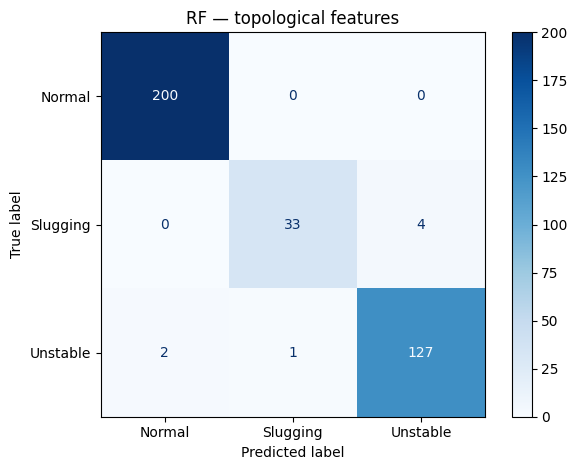

Recall: 0.9563  Precision: 0.9767  F1: 0.9659


In [22]:
# Random Forest (paper Fig. 10b)
clf_f = RandomForestClassifier(n_estimators=100, random_state=42)
clf_f.fit(X_tr_f, y_tr_f)
y_pred_rf = clf_f.predict(X_te_f)
print(f"RF accuracy: {clf_f.score(X_te_f, y_te_f):.4f}")
show_cm(y_te_f, y_pred_rf, ft_ternary, "RF — topological features")
show_metrics(y_te_f, y_pred_rf)

In [23]:
# Feature importances (paper Table II)
feat_names = ['Max Pers H0','Max Pers H1','Betti mean H0','Betti mean H1',
              'Entropy Norm H0','Entropy Norm H1']
imp = pd.Series(clf_f.feature_importances_, index=feat_names).sort_values(ascending=False)
print(imp)

Betti mean H0      0.299951
Max Pers H1        0.257936
Entropy Norm H0    0.159161
Max Pers H0        0.140017
Entropy Norm H1    0.086731
Betti mean H1      0.056205
dtype: float64


## 8. Feature ablation

Test how classification degrades when individual feature groups are removed.
All experiments use `labels_total` and the same `random_state=49` split.

In [24]:
# 6-column layout: [0]=MaxPH0, [1]=MaxPH1, [2]=BettiH0, [3]=BettiH1,
#                  [4]=EntrNormH0, [5]=EntrNormH1

ablations = {
    "No norm-entropy (cols 4,5 removed)":       np.delete(features_array, [4, 5], axis=1),
    "Persistence only (cols 0,1)":              features_array[:, [0, 1]],
    "Betti only (cols 2,3)":                    features_array[:, [2, 3]],
    "No persistence (cols 2,3,4,5)":            np.delete(features_array, [0, 1], axis=1),
}

for name, feats in ablations.items():
    X_tr, X_te, y_tr, y_te = train_test_split(feats, labels_total, test_size=0.35, random_state=49)
    lr_ab = LogisticRegression(multi_class="multinomial", max_iter=5000, solver='saga')
    lr_ab.fit(X_tr, y_tr)
    acc = lr_ab.score(X_te, y_te)
    cm  = metrics.confusion_matrix(y_te, lr_ab.predict(X_te))
    print(f"  {name}: {acc:.4f}  CM={cm.tolist()}")

  No norm-entropy (cols 4,5 removed): 0.9346  CM=[[186, 0, 14], [0, 31, 6], [4, 0, 126]]
  Persistence only (cols 0,1): 0.7602  CM=[[194, 0, 6], [0, 31, 6], [74, 2, 54]]


  Betti only (cols 2,3): 0.8283  CM=[[183, 0, 17], [4, 0, 33], [9, 0, 121]]


  No persistence (cols 2,3,4,5): 0.8202  CM=[[181, 6, 13], [7, 0, 30], [9, 1, 120]]
